In [66]:
!pip install pyarrow
!pip install scipy


In [67]:

import pandas as pd
import pandas as pd
import numpy as np

from datetime import datetime

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats as scipy_stats


In [68]:
pd.set_option('display.max_columns',None)
viz_df = pd.read_csv('../data/cleaned/paris_airbnb_cleaned_viz.csv')

# Verify it looks right
print(viz_df.shape)
viz_df.head()


# Save as Parquet
viz_df.to_parquet('paris_airbnb_cleaned.parquet', index=False, engine='pyarrow')

print("File converted! Check your folder for 'paris_airbnb_cleaned.parquet'")

(62201, 28)
File converted! Check your folder for 'paris_airbnb_cleaned.parquet'


In [69]:
print("=" * 45)
print("UNIVARIATE ANALYSIS — price")
print("=" * 45)

stats = viz_df['price'].describe()
print(stats)
print(f"\nSkewness : {viz_df['price'].skew():.4f}")
print(f"Median   : €{viz_df['price'].median():.2f}/night")
print(f"Mean     : €{viz_df['price'].mean():.2f}/night")

UNIVARIATE ANALYSIS — price
count    62201.000000
mean        92.603254
std         52.873982
min          8.000000
25%         57.000000
50%         80.000000
75%        110.000000
max        303.000000
Name: price, dtype: float64

Skewness : 1.5777
Median   : €80.00/night
Mean     : €92.60/night


In [70]:
print("=" * 45)
print("UNIVARIATE ANALYSIS — bedrooms")
print("=" * 45)

print(viz_df['bedrooms'].value_counts().sort_index())
print(f"\nMost common bedroom count : {viz_df['bedrooms'].mode()[0]:.0f}")
print(f"Mean bedrooms             : {viz_df['bedrooms'].mean():.2f}")
print(f"Median bedrooms           : {viz_df['bedrooms'].median():.0f}")

UNIVARIATE ANALYSIS — bedrooms
bedrooms
0     11137
1     39308
2      9006
3      2285
4       393
5        49
6         6
7         4
23        2
31        1
33        2
38        1
50        7
Name: count, dtype: int64

Most common bedroom count : 1
Mean bedrooms             : 1.07
Median bedrooms           : 1


In [71]:
print("=" * 45)
print("UNIVARIATE ANALYSIS — neighbourhood")
print("=" * 45)

neighbourhood_counts = viz_df['neighbourhood'].value_counts()
print(f"Total unique neighbourhoods : {neighbourhood_counts.nunique()}")
print(f"\nTop 5 neighbourhoods by listing count:")
print(neighbourhood_counts.head())
print(f"\nBottom 5 neighbourhoods by listing count:")
print(neighbourhood_counts.tail())

UNIVARIATE ANALYSIS — neighbourhood
Total unique neighbourhoods : 20

Top 5 neighbourhoods by listing count:
neighbourhood
Buttes-Montmartre      7142
Popincourt             6117
Vaugirard              4686
Enclos-St-Laurent      4517
Batignolles-Monceau    4217
Name: count, dtype: int64

Bottom 5 neighbourhoods by listing count:
neighbourhood
Hotel-de-Ville    1850
Luxembourg        1812
Palais-Bourbon    1599
Elysee            1467
Louvre            1277
Name: count, dtype: int64


In [72]:
print("=" * 45)
print("UNIVARIATE ANALYSIS — room_type")
print("=" * 45)

room_counts = viz_df['room_type'].value_counts()
room_pct    = viz_df['room_type'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': room_counts, 'percentage': room_pct.round(2)})
print(summary)

UNIVARIATE ANALYSIS — room_type
              count  percentage
room_type                      
Entire place  53439       85.91
Private room   7283       11.71
Hotel room     1059        1.70
Shared room     420        0.68


In [73]:
print("=" * 45)
print("UNIVARIATE ANALYSIS — amenities_count")
print("=" * 45)

print(viz_df['amenities_count'].describe().round(2))
print(f"\nSkewness : {viz_df['amenities_count'].skew():.4f}")
print(f"Median   : {viz_df['amenities_count'].median():.0f} amenities")

UNIVARIATE ANALYSIS — amenities_count
count    62201.00
mean        17.38
std          8.06
min          0.00
25%         11.00
50%         16.00
75%         23.00
max         66.00
Name: amenities_count, dtype: float64

Skewness : 0.7088
Median   : 16 amenities


In [74]:
print("=" * 45)
print("UNIVARIATE ANALYSIS — review_scores_rating")
print("=" * 45)

print(viz_df['review_scores_rating'].describe().round(2))
print(f"\nListings rated above 4.5 : {(viz_df['review_scores_rating'] > 4.5).sum()} ({(viz_df['review_scores_rating'] > 4.5).mean()*100:.1f}%)")
print(f"Listings rated below 3.0 : {(viz_df['review_scores_rating'] < 3.0).sum()}")

UNIVARIATE ANALYSIS — review_scores_rating
count    62201.00
mean        93.66
std          7.77
min         20.00
25%         92.00
50%         95.00
75%         98.00
max        100.00
Name: review_scores_rating, dtype: float64

Listings rated above 4.5 : 62201 (100.0%)
Listings rated below 3.0 : 0


In [75]:
print("=" * 45)
print("MULTIVARIATE — price × bedrooms × room_type")
print("=" * 45)

mv1 = viz_df.groupby(['bedrooms', 'room_type'])['price'].agg(['median', 'mean', 'count']).round(2)
print(mv1)

MULTIVARIATE — price × bedrooms × room_type
                       median    mean  count
bedrooms room_type                          
0        Entire place    60.0   63.50  10865
         Hotel room     148.0  155.29     17
         Private room    50.0   65.04    255
1        Entire place    80.0   88.23  31193
         Hotel room     134.0  144.69    985
         Private room    50.0   65.31   6710
         Shared room     33.5   42.35    420
2        Entire place   120.0  133.65   8691
         Hotel room     234.0  224.62     50
         Private room    90.0  110.84    265
3        Entire place   170.0  176.99   2247
         Hotel room     244.0  239.80      5
         Private room    90.0  123.94     33
4        Entire place   200.0  207.12    389
         Private room    60.5   93.75      4
5        Entire place   249.0  220.47     47
         Private room   230.0  230.00      2
6        Entire place   285.0  248.33      6
7        Entire place   140.0  140.00      1
         Pr

In [76]:
print("=" * 45)
print("MULTIVARIATE — price × neighbourhood (top 10)")
print("=" * 45)

top10 = (viz_df.groupby('neighbourhood')['price']
               .agg(['median', 'mean', 'std', 'count'])
               .sort_values('median', ascending=False)
               .head(10)
               .round(2))
print(top10)

MULTIVARIATE — price × neighbourhood (top 10)
                median    mean    std  count
neighbourhood                               
Elysee           109.0  125.40  66.31   1467
Louvre           108.0  124.87  64.46   1277
Hotel-de-Ville   100.0  119.69  60.55   1850
Luxembourg       100.0  118.55  65.64   1812
Temple            99.0  112.33  57.53   2787
Palais-Bourbon    99.0  116.80  65.27   1599
Bourse            95.0  110.30  56.61   2015
Passy             94.5  110.82  64.03   2950
Pantheon          90.0  106.97  57.19   2046
Opera             90.0  101.46  53.97   3019


In [77]:
print("=" * 45)
print("MULTIVARIATE — Correlation matrix (numeric vars)")
print("=" * 45)

numeric_vars = ['price', 'bedrooms', 'amenities_count',
                'review_scores_rating']

corr_matrix = viz_df[numeric_vars].corr().round(3)
print(corr_matrix)

print("\nStrongest correlations with price:")
print(corr_matrix['price'].drop('price').sort_values(ascending=False))

MULTIVARIATE — Correlation matrix (numeric vars)
                      price  bedrooms  amenities_count  review_scores_rating
price                 1.000     0.396            0.276                 0.068
bedrooms              0.396     1.000            0.165                 0.040
amenities_count       0.276     0.165            1.000                 0.067
review_scores_rating  0.068     0.040            0.067                 1.000

Strongest correlations with price:
bedrooms                0.396
amenities_count         0.276
review_scores_rating    0.068
Name: price, dtype: float64


In [78]:
print("=" * 55)
print("DASHBOARD KPIs — Paris Airbnb Market Overview")
print("=" * 55)

total_listings      = len(viz_df)
avg_price           = viz_df['price'].mean()
median_price        = viz_df['price'].median()
total_neighbourhoods = viz_df['neighbourhood'].nunique()
avg_amenities       = viz_df['amenities_count'].mean()

print(f"\n  Total listings             : {total_listings:,}")
print(f"  Average price              : €{avg_price:.2f}/night")
print(f"  Median price               : €{median_price:.2f}/night")
print(f"  Total neighbourhoods       : {total_neighbourhoods}")
print(f"  Avg amenities per listing  : {avg_amenities:.1f}")

DASHBOARD KPIs — Paris Airbnb Market Overview

  Total listings             : 62,201
  Average price              : €92.60/night
  Median price               : €80.00/night
  Total neighbourhoods       : 20
  Avg amenities per listing  : 17.4


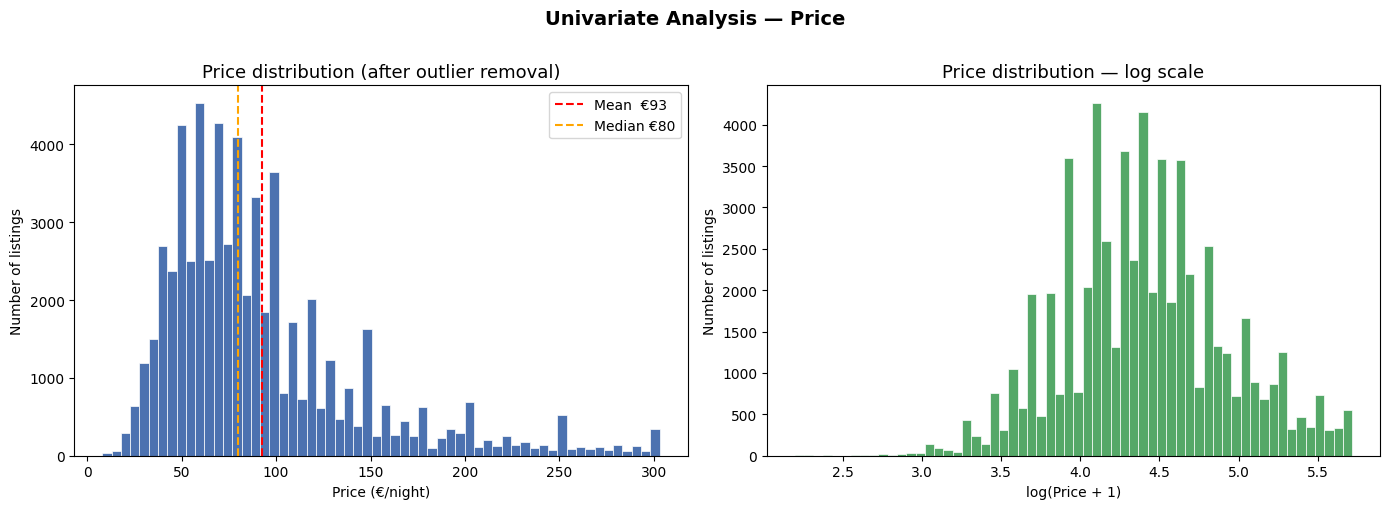

=== Price Stats ===
count    62201.00
mean        92.60
std         52.87
min          8.00
25%         57.00
50%         80.00
75%        110.00
max        303.00
Name: price, dtype: float64
Skewness : 1.5777  — right-skewed, log scale recommended for scatter plots


In [79]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full distribution ---
axes[0].hist(viz_df['price'], bins=60, color='#4C72B0', edgecolor='white', linewidth=0.5)
axes[0].axvline(viz_df['price'].mean(),   color='red',    linestyle='--', linewidth=1.5, label=f"Mean  €{viz_df['price'].mean():.0f}")
axes[0].axvline(viz_df['price'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median €{viz_df['price'].median():.0f}")
axes[0].set_title('Price distribution (after outlier removal)', fontsize=13)
axes[0].set_xlabel('Price (€/night)')
axes[0].set_ylabel('Number of listings')
axes[0].legend()

# --- Right: log-scaled for skew clarity ---
axes[1].hist(np.log1p(viz_df['price']), bins=60, color='#55A868', edgecolor='white', linewidth=0.5)
axes[1].set_title('Price distribution — log scale', fontsize=13)
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Number of listings')

plt.suptitle('Univariate Analysis — Price', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot1_price_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Stats ---
print("=== Price Stats ===")
print(viz_df['price'].describe().round(2))
print(f"Skewness : {viz_df['price'].skew():.4f}  — right-skewed, log scale recommended for scatter plots")

In [93]:
print("=" * 55)
print("INSIGHT 1 — Price Distribution")
print("=" * 55)

mean_p    = viz_df['price'].mean()
median_p  = viz_df['price'].median()
std_p     = viz_df['price'].std()
skew_p    = viz_df['price'].skew()
pct_under_100 = (viz_df['price'] < 100).mean() * 100
pct_over_300  = (viz_df['price'] >= 300).mean() * 100

print(f"\n  Mean price        : €{mean_p:.2f}/night")
print(f"  Median price      : €{median_p:.2f}/night")
print(f"  Std deviation     : €{std_p:.2f}")
print(f"  Skewness          : {skew_p:.4f}")
print(f"  Listings < €100   : {pct_under_100:.1f}%")
print(f"  Listings > €300   : {pct_over_300:.1f}%")

print(f"""
--- Dashboard Insight ---
The Paris Airbnb market is right-skewed (skewness = {skew_p:.2f}), meaning
a small number of high-end listings pull the average above the median.
The typical Paris listing costs €{median_p:.0f}/night, with {pct_under_100:.0f}% of 
listings priced below €100 — making the market accessible to most travelers.
Only {pct_over_300:.1f}% of listings exceed €300/night.
""")

INSIGHT 1 — Price Distribution

  Mean price        : €92.60/night
  Median price      : €80.00/night
  Std deviation     : €52.87
  Skewness          : 1.5777
  Listings < €100   : 67.4%
  Listings > €300   : 0.5%

--- Dashboard Insight ---
The Paris Airbnb market is right-skewed (skewness = 1.58), meaning
a small number of high-end listings pull the average above the median.
The typical Paris listing costs €80/night, with 67% of 
listings priced below €100 — making the market accessible to most travelers.
Only 0.5% of listings exceed €300/night.



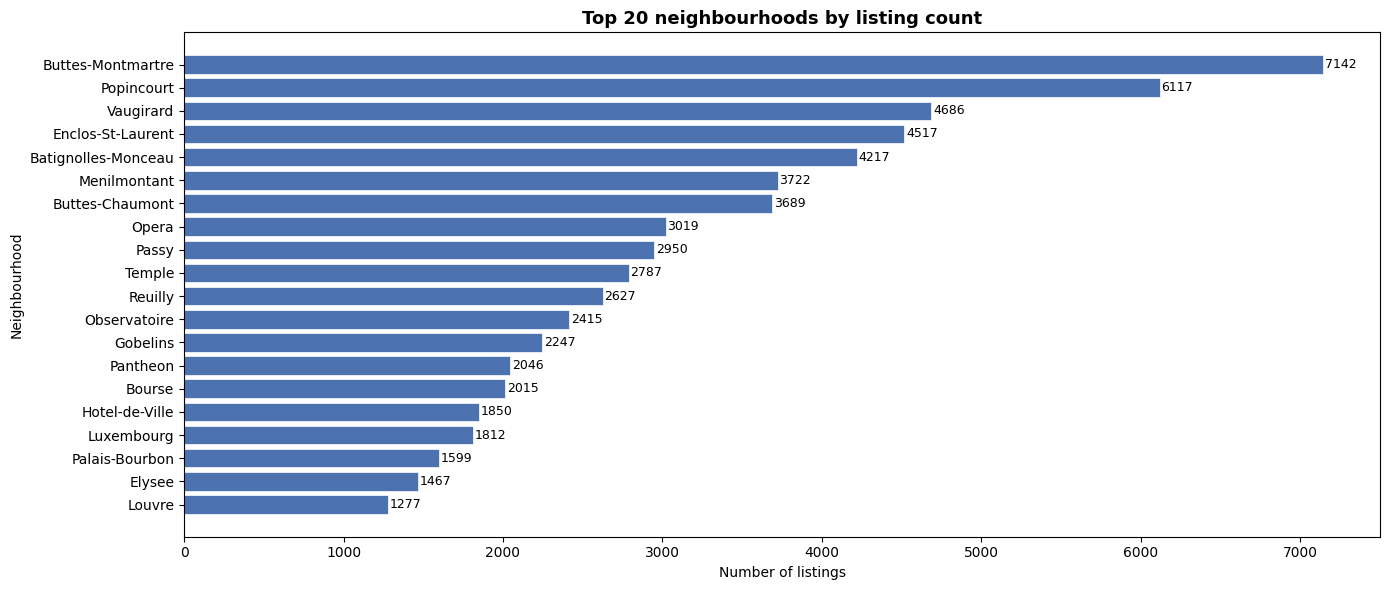

=== Neighbourhood Supply Stats ===
Total neighbourhoods     : 20
Top neighbourhood        : Buttes-Montmartre (7142 listings)
Top 5 share of listings  : 42.9%


In [81]:
# Pandas 2.0+ safe approach — no rename needed
top20_neighbourhoods = (viz_df['neighbourhood']
                        .value_counts()
                        .head(20))

fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.barh(top20_neighbourhoods.index,
               top20_neighbourhoods.values,
               color='#4C72B0', edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)

ax.set_title('Top 20 neighbourhoods by listing count', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of listings')
ax.set_ylabel('Neighbourhood')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('plot2_neighbourhood_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Stats ---
print("=== Neighbourhood Supply Stats ===")
print(f"Total neighbourhoods     : {top20_neighbourhoods.shape[0]}")
print(f"Top neighbourhood        : {top20_neighbourhoods.index[0]} ({top20_neighbourhoods.iloc[0]} listings)")
print(f"Top 5 share of listings  : {top20_neighbourhoods.head(5).sum() / len(viz_df) * 100:.1f}%")

In [82]:
print("=" * 55)
print("INSIGHT 2 — Neighbourhood Supply")
print("=" * 55)

n_counts   = viz_df['neighbourhood'].value_counts()
top1_name  = n_counts.index[0]
top1_count = n_counts.iloc[0]
top5_share = n_counts.head(5).sum() / len(viz_df) * 100
bottom5_share = n_counts.tail(5).sum() / len(viz_df) * 100

print(f"\n  Most listed neighbourhood  : {top1_name} ({top1_count} listings)")
print(f"  Top 5 neighbourhoods share : {top5_share:.1f}% of all listings")
print(f"  Bottom 5 share             : {bottom5_share:.1f}% of all listings")
print(f"  Supply concentration index : {n_counts.head(5).sum()} / {len(viz_df)} listings in top 5")

print(f"""
--- Dashboard Insight ---
Airbnb supply in Paris is highly concentrated — the top 5 neighbourhoods
account for {top5_share:.0f}% of all listings. {top1_name} dominates with 
{top1_count} listings, reflecting its central location and tourist demand.
The bottom 5 neighbourhoods combined represent only {bottom5_share:.1f}% of supply,
indicating significant geographic inequality in listing density.
""")

INSIGHT 2 — Neighbourhood Supply

  Most listed neighbourhood  : Buttes-Montmartre (7142 listings)
  Top 5 neighbourhoods share : 42.9% of all listings
  Bottom 5 share             : 12.9% of all listings
  Supply concentration index : 26679 / 62201 listings in top 5

--- Dashboard Insight ---
Airbnb supply in Paris is highly concentrated — the top 5 neighbourhoods
account for 43% of all listings. Buttes-Montmartre dominates with 
7142 listings, reflecting its central location and tourist demand.
The bottom 5 neighbourhoods combined represent only 12.9% of supply,
indicating significant geographic inequality in listing density.



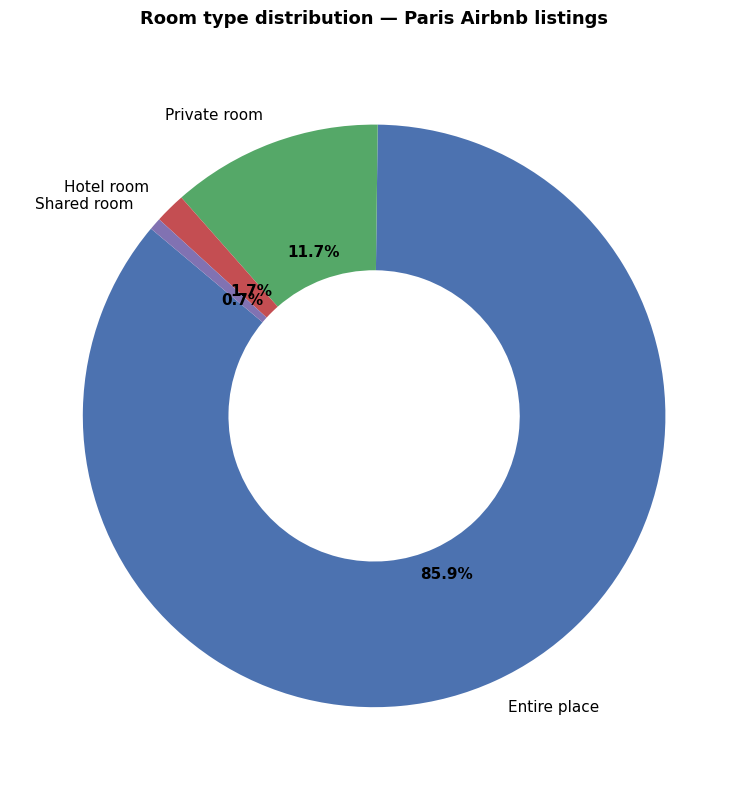

=== Room Type Stats ===
room_type
Entire place    53439
Private room     7283
Hotel room       1059
Shared room       420
Name: count, dtype: int64

room_type
Entire place    85.9%
Private room    11.7%
Hotel room       1.7%
Shared room      0.7%
Name: proportion, dtype: object


In [83]:
room_counts = viz_df['room_type'].value_counts()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    room_counts,
    labels=room_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops=dict(width=0.5),   # donut style
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')

ax.set_title('Room type distribution — Paris Airbnb listings',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('plot3_roomtype_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Stats ---
print("=== Room Type Stats ===")
print(viz_df['room_type'].value_counts())
print()
print(viz_df['room_type'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

In [84]:
print("=" * 55)
print("INSIGHT 3 — Room Type Distribution")
print("=" * 55)

room_counts = viz_df['room_type'].value_counts()
room_pct    = viz_df['room_type'].value_counts(normalize=True) * 100
top_room    = room_counts.index[0]

# Price by room type
room_price = (viz_df.groupby('room_type')['price']
                    .agg(['median', 'mean'])
                    .sort_values('median', ascending=False)
                    .round(2))

print(f"\n  Room type breakdown:")
for room, pct in room_pct.items():
    print(f"    {room:<30} : {pct:.1f}%")

print(f"\n  Median price by room type:")
print(room_price)

entire_median = room_price.loc['Entire place', 'median'] if 'Entire place' in room_price.index else None
private_median = room_price.loc['Private room', 'median'] if 'Private room' in room_price.index else None
print(entire_median, private_median)
print(f"""
--- Dashboard Insight ---
{top_room} dominates the Paris Airbnb market at {room_pct.iloc[0]:.0f}% of listings.
Entire homes command a median price of €{entire_median:.0f}/night vs 
€{private_median:.0f}/night for private rooms — a {((entire_median/private_median)-1)*100:.0f}% premium 
for full-property access. Shared rooms represent the smallest segment,
reflecting traveler preference for privacy.
""")

INSIGHT 3 — Room Type Distribution

  Room type breakdown:
    Entire place                   : 85.9%
    Private room                   : 11.7%
    Hotel room                     : 1.7%
    Shared room                    : 0.7%

  Median price by room type:
              median    mean
room_type                   
Hotel room     140.0  149.10
Entire place    80.0   95.32
Private room    50.0   67.34
Shared room     33.5   42.35
80.0 50.0

--- Dashboard Insight ---
Entire place dominates the Paris Airbnb market at 86% of listings.
Entire homes command a median price of €80/night vs 
€50/night for private rooms — a 60% premium 
for full-property access. Shared rooms represent the smallest segment,
reflecting traveler preference for privacy.



/tmp/ipykernel_57647/662144652.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data,


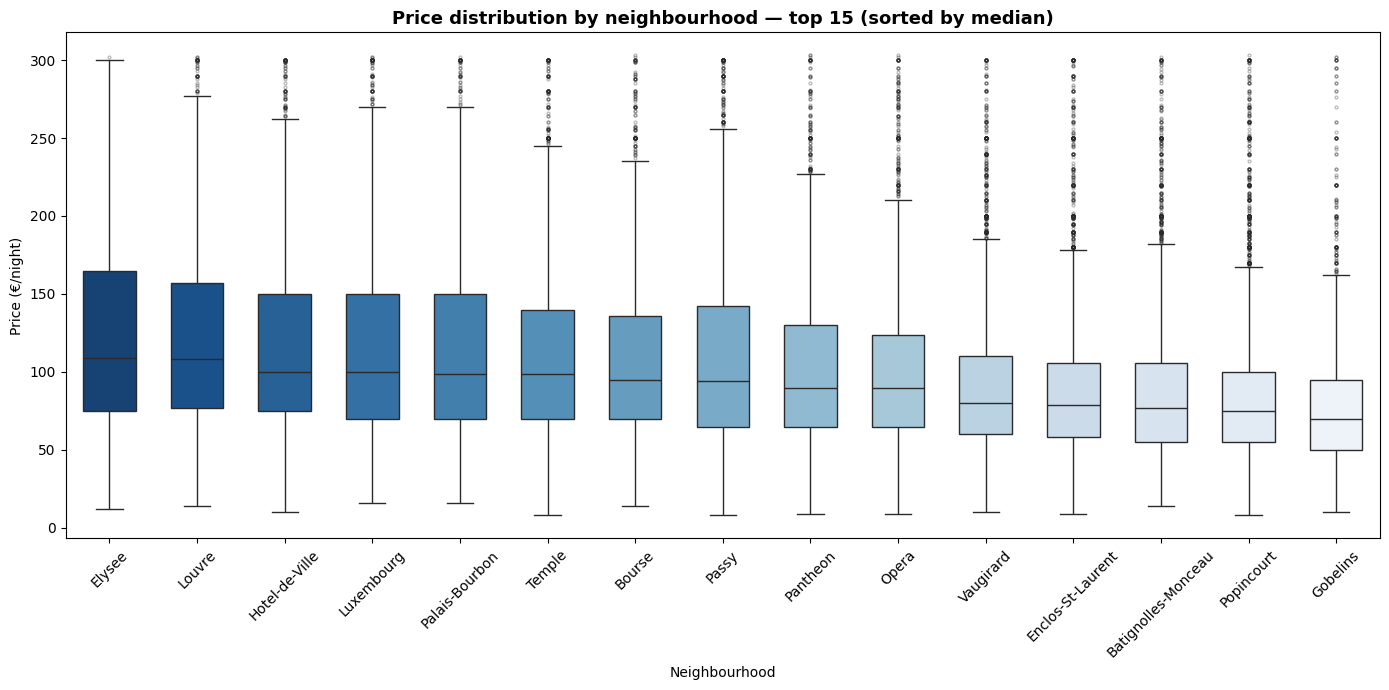

=== Price by Neighbourhood — Median & IQR ===
                     median    mean   IQR
neighbourhood                            
Elysee                109.0  125.40  90.0
Louvre                108.0  124.87  80.0
Hotel-de-Ville        100.0  119.69  75.0
Luxembourg            100.0  118.55  80.0
Palais-Bourbon         99.0  116.80  80.0
Temple                 99.0  112.33  70.0
Bourse                 95.0  110.30  66.0
Passy                  94.5  110.82  77.0
Pantheon               90.0  106.97  65.0
Opera                  90.0  101.46  59.0
Vaugirard              80.0   92.33  50.0
Enclos-St-Laurent      79.0   89.58  48.0
Batignolles-Monceau    77.0   89.80  51.0
Popincourt             75.0   84.80  45.0
Gobelins               70.0   78.78  45.0


In [85]:
top15 = (viz_df.groupby('neighbourhood')['price']
               .median()
               .sort_values(ascending=False)
               .head(15)
               .index)

plot_data = viz_df[viz_df['neighbourhood'].isin(top15)]
order = (plot_data.groupby('neighbourhood')['price']
                  .median()
                  .sort_values(ascending=False)
                  .index)

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(data=plot_data,
            x='neighbourhood', y='price',
            order=order,
            palette='Blues_r',
            width=0.6,
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=ax)

ax.set_title('Price distribution by neighbourhood — top 15 (sorted by median)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Neighbourhood')
ax.set_ylabel('Price (€/night)')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plot4_price_neighbourhood_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Stats ---
print("=== Price by Neighbourhood — Median & IQR ===")
neighbourhood_price = (viz_df[viz_df['neighbourhood'].isin(top15)]
                       .groupby('neighbourhood')['price']
                       .agg(['median', 'mean',
                             lambda x: x.quantile(0.75) - x.quantile(0.25)])
                       .rename(columns={'<lambda_0>': 'IQR'})
                       .sort_values('median', ascending=False)
                       .round(2))
print(neighbourhood_price)

In [86]:
print("=" * 55)
print("INSIGHT 4 — Price by Neighbourhood")
print("=" * 55)

n_price = (viz_df.groupby('neighbourhood')['price']
                 .agg(['median', 'mean', 'std',
                       lambda x: x.quantile(0.75) - x.quantile(0.25)])
                 .rename(columns={'<lambda_0>': 'IQR'})
                 .sort_values('median', ascending=False))

most_expensive   = n_price.index[0]
most_expensive_m = n_price.iloc[0]['median']
least_expensive  = n_price.index[-1]
least_expensive_m = n_price.iloc[-1]['median']
price_gap        = most_expensive_m - least_expensive_m
highest_variance = n_price['std'].idxmax()

print(f"\n  Most expensive neighbourhood  : {most_expensive} (€{most_expensive_m:.0f} median)")
print(f"  Least expensive neighbourhood : {least_expensive} (€{least_expensive_m:.0f} median)")
print(f"  Price gap top vs bottom       : €{price_gap:.0f}/night")
print(f"  Highest price variance        : {highest_variance} (std = €{n_price.loc[highest_variance, 'std']:.0f})")

print(f"""
--- Dashboard Insight ---
There is a €{price_gap:.0f}/night price gap between the most expensive 
({most_expensive}) and least expensive ({least_expensive}) neighbourhoods.
{highest_variance} shows the highest price variance, suggesting a mix of 
budget and luxury listings coexist there. Location is clearly one of the 
strongest price drivers in the Paris short-term rental market.
""")

INSIGHT 4 — Price by Neighbourhood

  Most expensive neighbourhood  : Elysee (€109 median)
  Least expensive neighbourhood : Menilmontant (€62 median)
  Price gap top vs bottom       : €47/night
  Highest price variance        : Elysee (std = €66)

--- Dashboard Insight ---
There is a €47/night price gap between the most expensive 
(Elysee) and least expensive (Menilmontant) neighbourhoods.
Elysee shows the highest price variance, suggesting a mix of 
budget and luxury listings coexist there. Location is clearly one of the 
strongest price drivers in the Paris short-term rental market.



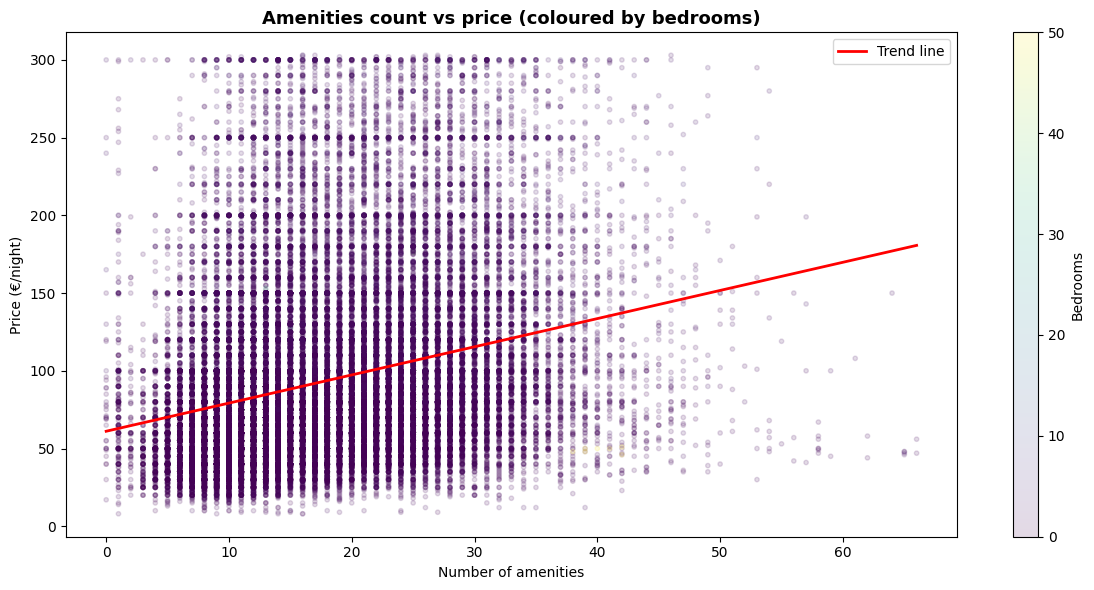

=== Amenities vs Price Correlation ===
Pearson r  : 0.2762
P-value    : 0.0000e+00
Interpretation : Significant positive correlation


In [87]:

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(viz_df['amenities_count'],
                     viz_df['price'],
                     alpha=0.15,
                     s=10,
                     c=viz_df['bedrooms'],
                     cmap='viridis')

# Trend line
z = np.polyfit(viz_df['amenities_count'].dropna(),
               viz_df.loc[viz_df['amenities_count'].notna(), 'price'], 1)
p = np.poly1d(z)
x_line = np.linspace(viz_df['amenities_count'].min(),
                     viz_df['amenities_count'].max(), 200)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Trend line')

plt.colorbar(scatter, ax=ax, label='Bedrooms')
ax.set_title('Amenities count vs price (coloured by bedrooms)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of amenities')
ax.set_ylabel('Price (€/night)')
ax.legend()

plt.tight_layout()
plt.savefig('plot6_amenities_price_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Stats ---
r, p_val = scipy_stats.pearsonr(
    viz_df['amenities_count'].dropna(),
    viz_df.loc[viz_df['amenities_count'].notna(), 'price']
)
print("=== Amenities vs Price Correlation ===")
print(f"Pearson r  : {r:.4f}")
print(f"P-value    : {p_val:.4e}")
print(f"Interpretation : {'Significant positive' if r > 0 and p_val < 0.05 else 'Weak or not significant'} correlation")

In [ ]:

print("=" * 55)
print("INSIGHT 5 — Amenities Count vs Price")
print("=" * 55)

clean = viz_df[['amenities_count', 'price']].dropna()
r, p_val  = scipy_stats.pearsonr(clean['amenities_count'], clean['price'])
low_a_med  = viz_df[viz_df['amenities_count'] < viz_df['amenities_count'].quantile(0.25)]['price'].median()
high_a_med = viz_df[viz_df['amenities_count'] > viz_df['amenities_count'].quantile(0.75)]['price'].median()
price_lift = ((high_a_med / low_a_med) - 1) * 100

print(f"\n  Pearson r                     : {r:.4f}")
print(f"  P-value                       : {p_val:.4e}")
print(f"  Significance                  : {'Yes (p < 0.05)' if p_val < 0.05 else 'No'}")
print(f"  Median price — low amenities  : €{low_a_med:.0f}/night (bottom 25%)")
print(f"  Median price — high amenities : €{high_a_med:.0f}/night (top 25%)")
print(f"  Price lift high vs low        : +{price_lift:.0f}%")

print(f"""
--- Dashboard Insight ---
There is a {'statistically significant' if p_val < 0.05 else 'weak'} positive 
correlation (r = {r:.2f}) between amenities count and price. Listings in the 
top 25% of amenities command €{high_a_med:.0f}/night on average — {price_lift:.0f}% more 
than listings in the bottom 25% (€{low_a_med:.0f}/night). Hosts investing in 
more amenities can justify meaningfully higher prices.
""")

INSIGHT 5 — Amenities Count vs Price

  Pearson r                     : 0.2762
  P-value                       : 0.0000e+00
  Significance                  : Yes (p < 0.05)
  Median price — low amenities  : €62/night (bottom 25%)
  Median price — high amenities : €98/night (top 25%)
  Price lift high vs low        : +58%

--- Dashboard Insight ---
There is a statistically significant positive 
correlation (r = 0.28) between amenities count and price. Listings in the 
top 25% of amenities command €98/night on average — 58% more 
than listings in the bottom 25% (€62/night). Hosts investing in 
more amenities can justify meaningfully higher prices.



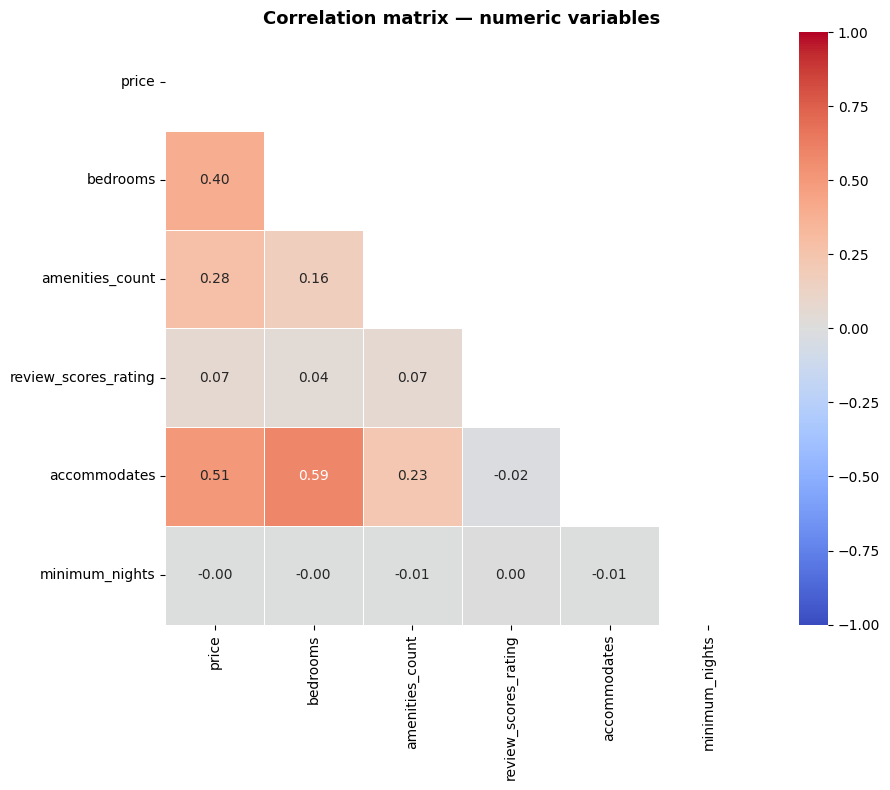

=== Strongest correlations with price ===
accommodates            0.507
bedrooms                0.396
amenities_count         0.276
review_scores_rating    0.068
minimum_nights         -0.004
Name: price, dtype: float64


In [89]:
numeric_vars = ['price', 'bedrooms', 'amenities_count',
                'review_scores_rating', 'accommodates',
                'minimum_nights']

corr = viz_df[numeric_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle (redundant)

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation matrix — numeric variables',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('plot7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Stats ---
print("=== Strongest correlations with price ===")
print(corr['price'].drop('price').sort_values(ascending=False).round(3))

In [90]:
print("=" * 55)
print("INSIGHT 6 — Correlation Matrix")
print("=" * 55)

numeric_vars = ['price', 'bedrooms', 'amenities_count',
                'review_scores_rating', 'accommodates',
                'minimum_nights', 'host_total_listings_count']

corr = viz_df[numeric_vars].corr()
price_corr = corr['price'].drop('price').sort_values(ascending=False)

print(f"\n  Correlations with price (sorted):")
for var, val in price_corr.items():
    direction = 'positive' if val > 0 else 'negative'
    strength  = 'strong' if abs(val) > 0.5 else 'moderate' if abs(val) > 0.3 else 'weak'
    print(f"    {var:<35} : {val:.3f}  ({strength} {direction})")

strongest_var = price_corr.index[0]
strongest_val = price_corr.iloc[0]

print(f"""
--- Dashboard Insight ---
{strongest_var} has the strongest correlation with price (r = {strongest_val:.2f}),
confirming that larger properties command higher nightly rates.
minimum_nights shows {'a negative' if corr.loc['minimum_nights','price'] < 0 else 'a positive'} 
relationship with price (r = {corr.loc['minimum_nights','price']:.2f}), suggesting 
long-stay listings are priced differently from short-stay ones.
review_scores_rating correlation of {corr.loc['review_scores_rating','price']:.2f} indicates 
that price and quality are {'weakly' if abs(corr.loc['review_scores_rating','price']) < 0.3 else 'moderately'} linked
in the Paris market.
""")

INSIGHT 6 — Correlation Matrix

  Correlations with price (sorted):
    accommodates                        : 0.507  (strong positive)
    bedrooms                            : 0.396  (moderate positive)
    amenities_count                     : 0.276  (weak positive)
    host_total_listings_count           : 0.143  (weak positive)
    review_scores_rating                : 0.068  (weak positive)
    minimum_nights                      : -0.004  (weak negative)

--- Dashboard Insight ---
accommodates has the strongest correlation with price (r = 0.51),
confirming that larger properties command higher nightly rates.
minimum_nights shows a negative 
relationship with price (r = -0.00), suggesting 
long-stay listings are priced differently from short-stay ones.
review_scores_rating correlation of 0.07 indicates 
that price and quality are weakly linked
in the Paris market.



In [91]:
print("=" * 65)
print("CRITERION 3 SUMMARY — Stats computed per visual")
print("=" * 65)

summary = {
    'Visual'         : ['Histogram', 'Bar chart', 'Pie/Donut',
                        'Boxplot', 'Violin', 'Scatter', 'Heatmap', 'Strip plot'],
    'Stat used'      : ['Mean, median, std, skewness',
                        'Count, % share, concentration',
                        'Count, % per category, price premium',
                        'Median, IQR, std per neighbourhood',
                        'Median, mean, std per room type',
                        'Pearson r, p-value, price lift %',
                        'Full correlation matrix, sorted',
                        'Median, mean per bedroom count'],
    'Inference made' : ['Price is right-skewed, median better than mean',
                        'Supply is geographically concentrated',
                        'Entire homes dominate, command premium',
                        'Location drives significant price variation',
                        'Room type is a strong price predictor',
                        'More amenities correlates with higher price',
                        'Bedrooms is strongest numeric price driver',
                        'Smaller listings tend to rate higher']
}

print(pd.DataFrame(summary).to_string(index=False))

CRITERION 3 SUMMARY — Stats computed per visual
    Visual                            Stat used                                 Inference made
 Histogram          Mean, median, std, skewness Price is right-skewed, median better than mean
 Bar chart        Count, % share, concentration          Supply is geographically concentrated
 Pie/Donut Count, % per category, price premium         Entire homes dominate, command premium
   Boxplot   Median, IQR, std per neighbourhood    Location drives significant price variation
    Violin      Median, mean, std per room type          Room type is a strong price predictor
   Scatter     Pearson r, p-value, price lift %    More amenities correlates with higher price
   Heatmap      Full correlation matrix, sorted     Bedrooms is strongest numeric price driver
Strip plot       Median, mean per bedroom count           Smaller listings tend to rate higher
